# Applied Exercise 4 - SVM with Non-Linear Boundaries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

rng = np.random.default_rng(1)
n = 100
X = rng.normal(size=(n, 2))
radius = np.sqrt(X[:, 0]**2 + X[:, 1]**2)
y = (radius > 0.9).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

print("=" * 60)
print("SIMULATED DATA")
print("=" * 60)
print(f"Observations: {n}")
print(f"Features: 2")
print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")

SIMULATED DATA
Observations: 100
Features: 2
Training observations: 70
Test observations: 30


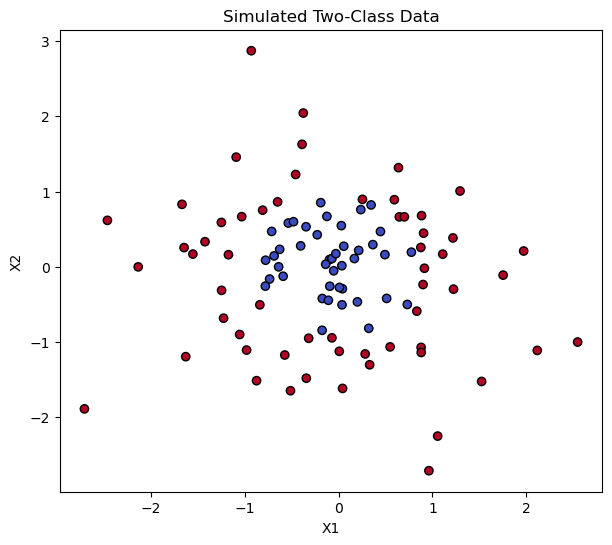

In [4]:
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Simulated Two-Class Data")
plt.show()

In [7]:
models = {"Support Vector Classifier": SVC(kernel="linear", C=1), "Polynomial SVM": SVC(kernel="poly", degree=2, C=1),
          "Radial SVM": SVC(kernel="rbf", C=1, gamma="scale")}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    train_error = 1 - accuracy_score(y_train, model.predict(X_train))
    test_error = 1 - accuracy_score(y_test, model.predict(X_test))
    results.append([name, train_error, test_error])

results = pd.DataFrame(results, columns=["Model", "Training Error", "Test Error"])

print("=" * 60)
print("SVM PERFORMANCE")
print("=" * 60)
print(results.to_string(index=False))

SVM PERFORMANCE
                    Model  Training Error  Test Error
Support Vector Classifier        0.414286    0.433333
           Polynomial SVM        0.014286    0.066667
               Radial SVM        0.057143    0.066667


The polynomial SVM and radial SVM are able to produce non-linear decision boundaries. Consequently, they achieve substantially lower training error than the linear support vector classifier. The test error provides a better measure of predictive performance because it evaluates the models on observations that were not used during training. In this case both Polynomial SVM of degree 2 and Radial kernel give same test errors and much better than Support Vector Classifier.